<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana4/clustering_kmeans_wholesale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering no supervisado con K-Means

## Caso: segmentación de clientes de un distribuidor mayorista

**Objetivo de la clase:** identificar estructuras ocultas en datos **sin etiquetas** y explorar:

- concepto de agrupamiento no supervisado;
- algoritmo K-Means;
- inicialización aleatoria y `k-means++`;
- selección de \(K\) mediante método del codo;
- inercia;
- `silhouette score`;
- interpretación de clusters.

Usaremos el dataset **Wholesale Customers** de UCI. Cada fila representa un cliente y las variables indican su gasto anual en distintas categorías de productos.

## 1. ¿Qué cambia respecto al aprendizaje supervisado?

En aprendizaje supervisado teníamos

\[
X \longrightarrow y
\]

porque conocíamos una etiqueta o variable objetivo.

En clustering sólo tenemos

\[
\boxed{X}
\]

y queremos descubrir si dentro de esos datos existen grupos con patrones similares.

> **Pregunta de negocio:** sin conocer de antemano el tipo de cliente, ¿podemos encontrar segmentos con comportamientos de compra diferentes?

In [ ]:
# ============================================================
# 0. LIBRERÍAS Y CONFIGURACIÓN
# ============================================================

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
N_INIT = 30
K_MIN = 2
K_MAX = 10

# Cambia a False si quieres imponer manualmente otro K para explorar.
USAR_K_AUTOMATICO = True
K_MANUAL = 3

RUTA_SALIDAS = Path("salidas_clustering")
RUTA_SALIDAS.mkdir(exist_ok=True)

VARIABLES_GASTO = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen",
]

print("Carpeta de salidas:", RUTA_SALIDAS.resolve())

def guardar_y_mostrar(nombre):
    """Guarda la figura actual y luego la muestra en el notebook."""
    ruta = RUTA_SALIDAS / nombre
    plt.tight_layout()
    plt.savefig(ruta, dpi=180, bbox_inches="tight")
    plt.show()
    print("Figura guardada en:", ruta)


Carpeta de salidas: /content/salidas_clustering


## 2. Cargar el dataset

El notebook busca primero una copia local en `data/Wholesale_customers_data.csv`.

En Google Colab esa carpeta normalmente no existe al comienzo, así que el código descarga automáticamente una copia pública del dataset.

El dataset original está documentado en **UCI Machine Learning Repository, ID 292**.

In [ ]:
# ============================================================
# 1. CARGA DE DATOS
# ============================================================

RUTA_LOCAL = Path("data") / "Wholesale_customers_data.csv"

URL_RESPALDO = (
    "https://raw.githubusercontent.com/TrainingByPackt/"
    "Data-Science-with-Python/refs/heads/master/"
    "Chapter01/Data/Wholesale%20customers%20data.csv"
)

if RUTA_LOCAL.exists():
    print("Leyendo archivo local:", RUTA_LOCAL)
    df = pd.read_csv(RUTA_LOCAL)
else:
    print("No se encontró el archivo local.")
    print("Descargando una copia pública del dataset...")
    df = pd.read_csv(URL_RESPALDO)

print("Dimensiones:", df.shape)
display(df.head())

No se encontró el archivo local.
Descargando una copia pública del dataset...
Dimensiones: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
print("Columnas:")
print(list(df.columns))

print("\nDatos faltantes:")
display(df.isna().sum().to_frame("N_faltantes"))

print("\nResumen estadístico:")
display(df.describe().T.round(2))

Columnas:
['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

Datos faltantes:


,N_faltantes
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0



Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.32,0.47,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.54,0.77,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.30,12647.33,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.27,7380.38,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.28,9503.16,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.93,4854.67,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.49,4767.85,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.87,2820.11,3.0,408.25,965.5,1820.25,47943.0


## 3. Variables utilizadas

Para el clustering utilizaremos únicamente los seis gastos:

\[
x_i =
(\text{Fresh},\text{Milk},\text{Grocery},\text{Frozen},
\text{Detergents},\text{Delicassen})
\]

No utilizaremos `Channel` ni `Region` para construir los clusters.

Esto permite plantear el problema genuinamente como **no supervisado**.

In [ ]:
X = df[VARIABLES_GASTO].copy()

print("Matriz X:", X.shape)
display(X.head())

Matriz X: (440, 6)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


## 4. Mirar primero los datos sin etiquetas

Antes de entrenar cualquier algoritmo, observemos dos variables.

No existe todavía ningún color que represente una clase conocida.

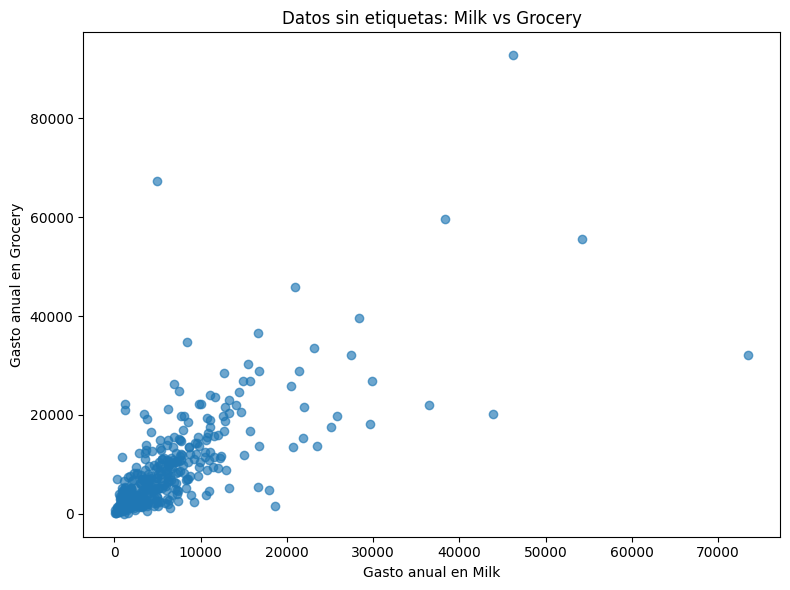

Figura guardada en: salidas_clustering/01_datos_sin_etiquetas_milk_grocery.png


In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X["Milk"], X["Grocery"], alpha=0.65)
plt.xlabel("Gasto anual en Milk")
plt.ylabel("Gasto anual en Grocery")
plt.title("Datos sin etiquetas: Milk vs Grocery")
guardar_y_mostrar("01_datos_sin_etiquetas_milk_grocery.png")

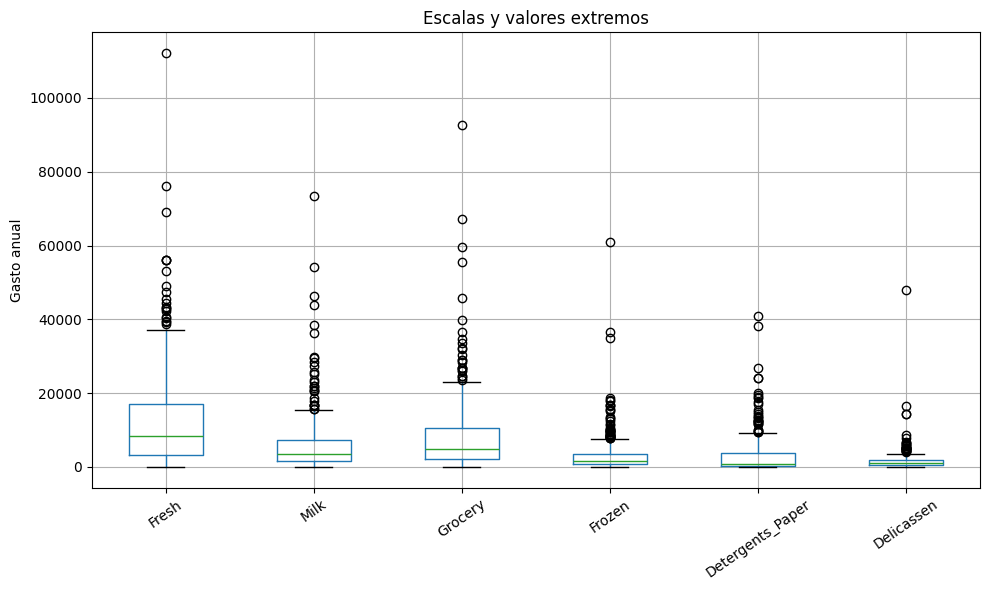

Figura guardada en: salidas_clustering/02_boxplot_variables_originales.png


In [ ]:
plt.figure(figsize=(10, 6))
X.boxplot(rot=35)
plt.ylabel("Gasto anual")
plt.title("Escalas y valores extremos")
guardar_y_mostrar("02_boxplot_variables_originales.png")

## 5. ¿Por qué debemos escalar?

K-Means está basado en distancia euclidiana:

\[
d(\mathbf{x},\boldsymbol{\mu}) =
\sqrt{\sum_j (x_j-\mu_j)^2}.
\]

Una variable con una escala numérica mucho mayor puede dominar la distancia.

Usaremos

\[
z=\frac{x-\mu}{\sigma}
\]

mediante `StandardScaler`.

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=VARIABLES_GASTO
)

print("Medias después de escalar:")
print(np.round(X_scaled.mean(axis=0), 6))

print("\nDesviaciones estándar:")
print(np.round(X_scaled.std(axis=0), 6))

display(X_scaled_df.head())

Medias después de escalar:
[-0.  0. -0.  0.  0. -0.]

Desviaciones estándar:
[1. 1. 1. 1. 1. 1.]


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


# 6. K-Means: idea geométrica

Supongamos que elegimos \(K=3\).

K-Means repite dos operaciones:

### A. Asignación

Cada dato se asigna al centroide más cercano:

\[
c_i = \arg\min_k
\left\|\mathbf{x}_i-\boldsymbol{\mu}_k\right\|^2.
\]

### B. Actualización

Cada centroide se reemplaza por la media de los puntos asignados:

\[
\boldsymbol{\mu}_k =
\frac{1}{N_k}
\sum_{i:c_i=k}\mathbf{x}_i.
\]

Y se repite:

\[
\boxed{\text{Asignar}\rightarrow\text{Actualizar}\rightarrow
\text{Asignar}\rightarrow\text{Actualizar}\rightarrow\cdots}
\]

## 7. Una iteración manual para ver qué hace el algoritmo

Usaremos sólo `Milk` y `Grocery` para poder dibujar el procedimiento.

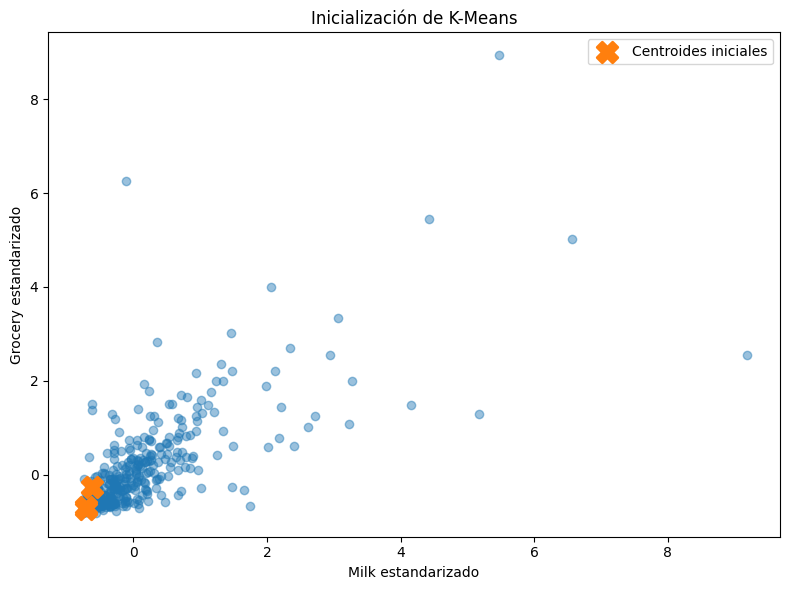

Figura guardada en: salidas_clustering/03_kmeans_centroides_iniciales.png


In [ ]:
idx_milk = VARIABLES_GASTO.index("Milk")
idx_grocery = VARIABLES_GASTO.index("Grocery")

X_demo = X_scaled[:, [idx_milk, idx_grocery]]

rng = np.random.default_rng(RANDOM_STATE)

# Elegimos tres clientes como centroides iniciales.
indices_iniciales = rng.choice(
    len(X_demo),
    size=3,
    replace=False
)

centroides_iniciales = X_demo[indices_iniciales].copy()

plt.figure(figsize=(8, 6))
plt.scatter(X_demo[:, 0], X_demo[:, 1], alpha=0.45)
plt.scatter(
    centroides_iniciales[:, 0],
    centroides_iniciales[:, 1],
    marker="X",
    s=220,
    linewidths=2,
    label="Centroides iniciales"
)
plt.xlabel("Milk estandarizado")
plt.ylabel("Grocery estandarizado")
plt.title("Inicialización de K-Means")
plt.legend()
guardar_y_mostrar("03_kmeans_centroides_iniciales.png")

In [ ]:
# PASO 1: calcular distancia de cada punto a cada centroide.
distancias = np.sum(
    (X_demo[:, np.newaxis, :] -
     centroides_iniciales[np.newaxis, :, :])**2,
    axis=2
)

print("Forma de la matriz de distancias:", distancias.shape)

# PASO 2: asignar cada cliente al centroide más cercano.
etiquetas_demo = np.argmin(distancias, axis=1)

# PASO 3: recalcular cada centroide como media del grupo.
centroides_actualizados = np.vstack([
    X_demo[etiquetas_demo == k].mean(axis=0)
    for k in range(3)
])

print("Centroides iniciales:\n", centroides_iniciales)
print("\nCentroides después de una actualización:\n", centroides_actualizados)

Forma de la matriz de distancias: (440, 3)
Centroides iniciales:
 [[-0.70568042 -0.70111952]
 [-0.71097072 -0.7426266 ]
 [-0.62510511 -0.27593538]]

Centroides después de una actualización:
 [[-0.52388655 -0.62396815]
 [-0.69461537 -0.77430622]
 [ 0.31643662  0.37158703]]


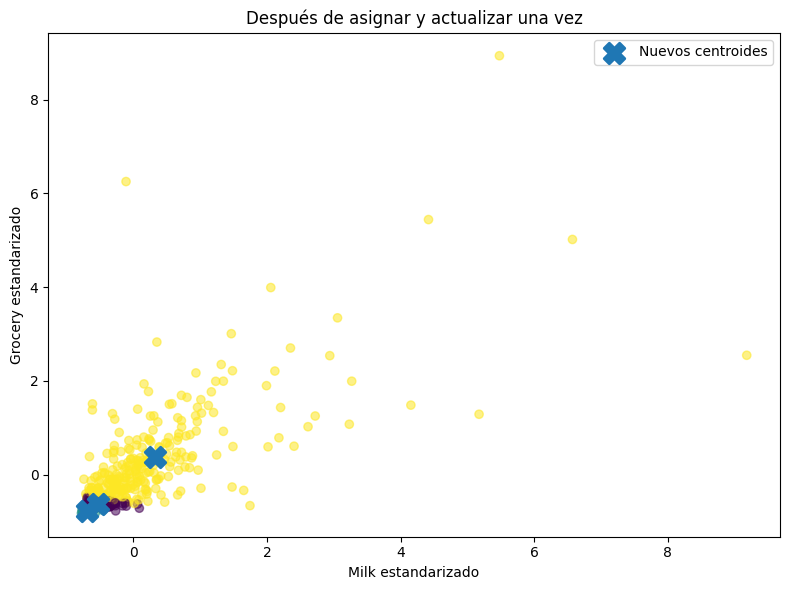

Figura guardada en: salidas_clustering/04_kmeans_primera_iteracion.png


In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_demo[:, 0],
    X_demo[:, 1],
    c=etiquetas_demo,
    alpha=0.55
)
plt.scatter(
    centroides_actualizados[:, 0],
    centroides_actualizados[:, 1],
    marker="X",
    s=220,
    linewidths=2,
    label="Nuevos centroides"
)
plt.xlabel("Milk estandarizado")
plt.ylabel("Grocery estandarizado")
plt.title("Después de asignar y actualizar una vez")
plt.legend()
guardar_y_mostrar("04_kmeans_primera_iteracion.png")

# 8. Función objetivo: inercia

K-Means intenta minimizar

\[
\boxed{
J =
\sum_{k=1}^{K}
\sum_{\mathbf{x}_i\in C_k}
\|\mathbf{x}_i-\boldsymbol{\mu}_k\|^2
}
\]

En `scikit-learn`:

```python
modelo.inertia_
```

Una inercia menor significa clusters más compactos.

Pero existe una trampa:

- si aumentamos \(K\), la inercia casi siempre disminuye;
- si \(K=N\), cada observación puede ser su propio cluster y la inercia sería cero.

Por eso **no elegimos \(K\) simplemente buscando la menor inercia**.

# 9. Inicialización: `random` vs `k-means++`

K-Means puede llegar a soluciones diferentes según dónde empiecen los centroides.

Vamos a usar `n_init=1` deliberadamente para hacer visible esa sensibilidad.

In [ ]:
semillas = [1, 5, 10, 25, 42, 75, 100, 250, 500, 1000]

filas = []

for semilla in semillas:
    for metodo in ["random", "k-means++"]:

        modelo = KMeans(
            n_clusters=3,
            init=metodo,
            n_init=1,
            random_state=semilla
        )

        modelo.fit(X_scaled)

        filas.append({
            "Semilla": semilla,
            "Inicializacion": metodo,
            "Inercia": modelo.inertia_
        })

df_init = pd.DataFrame(filas)

display(df_init.round(2))

,Semilla,Inicializacion,Inercia
0,1,random,1626.83
1,1,k-means++,1629.99
2,5,random,1642.75
3,5,k-means++,1642.43
4,10,random,1621.31
5,10,k-means++,1626.83
6,25,random,1610.17
7,25,k-means++,1642.25
8,42,random,1655.05
9,42,k-means++,1644.06


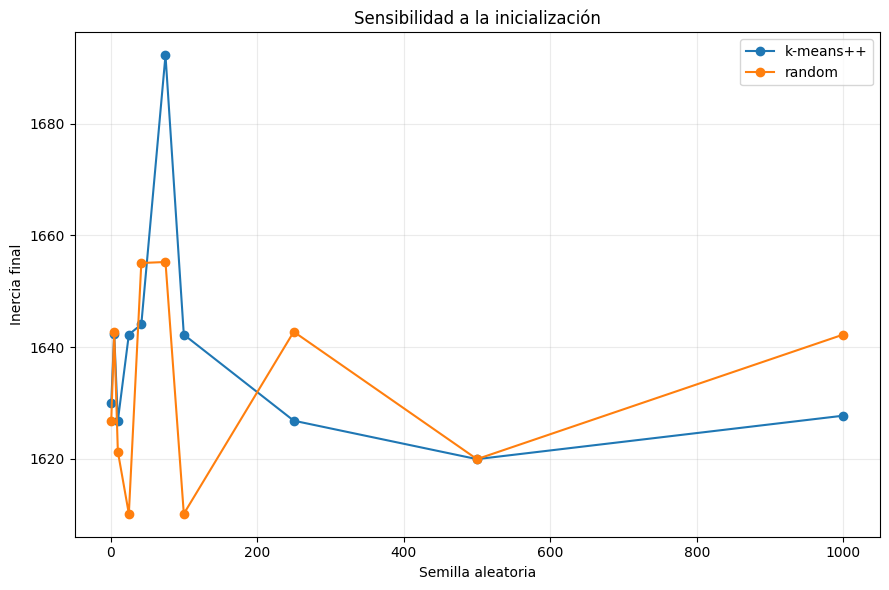

Figura guardada en: salidas_clustering/05_comparacion_inicializacion.png


In [ ]:
plt.figure(figsize=(9, 6))

for metodo, grupo in df_init.groupby("Inicializacion"):
    plt.plot(
        grupo["Semilla"],
        grupo["Inercia"],
        marker="o",
        label=metodo
    )

plt.xlabel("Semilla aleatoria")
plt.ylabel("Inercia final")
plt.title("Sensibilidad a la inicialización")
plt.legend()
plt.grid(alpha=0.25)
guardar_y_mostrar("05_comparacion_inicializacion.png")

### ¿Qué hace `k-means++`?

No coloca los centroides iniciales completamente al azar.

Busca iniciar los centros de manera que estén razonablemente separados, reduciendo la probabilidad de empezar con una configuración muy mala.

Además, en aplicaciones reales usamos varias inicializaciones:

```python
n_init=30
```

y conservamos la mejor solución encontrada.

# 10. ¿Cómo escoger \(K\)? — Método del codo

Calcularemos la inercia para

\[
K=1,2,\ldots,10.
\]

Buscamos visualmente el punto a partir del cual aumentar \(K\) produce mejoras cada vez menores.

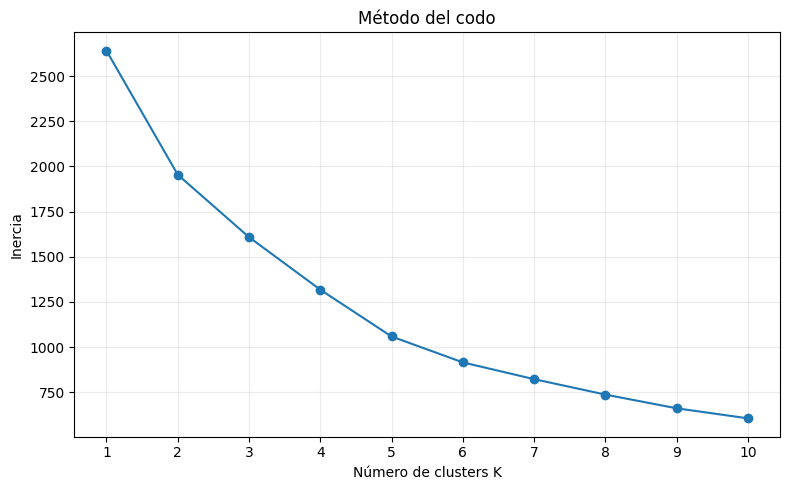

Figura guardada en: salidas_clustering/06_metodo_del_codo.png


In [ ]:
valores_k_codo = list(range(1, K_MAX + 1))
inercias = []

for k in valores_k_codo:

    modelo = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=N_INIT,
        random_state=RANDOM_STATE
    )

    modelo.fit(X_scaled)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(valores_k_codo, inercias, marker="o")
plt.xlabel("Número de clusters K")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.xticks(valores_k_codo)
plt.grid(alpha=0.25)
guardar_y_mostrar("06_metodo_del_codo.png")

# 11. Silhouette score

Para una observación \(i\):

- \(a(i)\): distancia promedio a los puntos de su propio cluster;
- \(b(i)\): distancia promedio al cluster vecino más cercano.

\[
\boxed{
s(i)=
\frac{b(i)-a(i)}
{\max(a(i),b(i))}
}
\]

con

\[
-1\leq s(i)\leq 1.
\]

Interpretación:

- \(s\approx 1\): observación bien agrupada;
- \(s\approx 0\): está cerca de una frontera;
- \(s<0\): podría estar mejor ubicada en otro cluster.

In [ ]:
resultados_k = []

for k in range(K_MIN, K_MAX + 1):

    modelo = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=N_INIT,
        random_state=RANDOM_STATE
    )

    etiquetas = modelo.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        etiquetas
    )

    tamanos = pd.Series(etiquetas).value_counts()

    resultados_k.append({
        "K": k,
        "Inercia": modelo.inertia_,
        "Silhouette": score,
        "Cluster_min": tamanos.min(),
        "Cluster_max": tamanos.max()
    })

df_resultados_k = pd.DataFrame(resultados_k)

display(df_resultados_k.round(4))

,K,Inercia,Silhouette,Cluster_min,Cluster_max
0,2,1954.0281,0.5811,40,400
1,3,1608.4311,0.5483,2,393
2,4,1317.8384,0.3485,5,315
3,5,1058.7713,0.3690,1,270
4,6,915.4985,0.3753,1,277
5,7,822.7225,0.3035,1,239
6,8,737.3862,0.3201,1,219
7,9,661.4496,0.3090,1,198
8,10,605.9151,0.3112,1,184


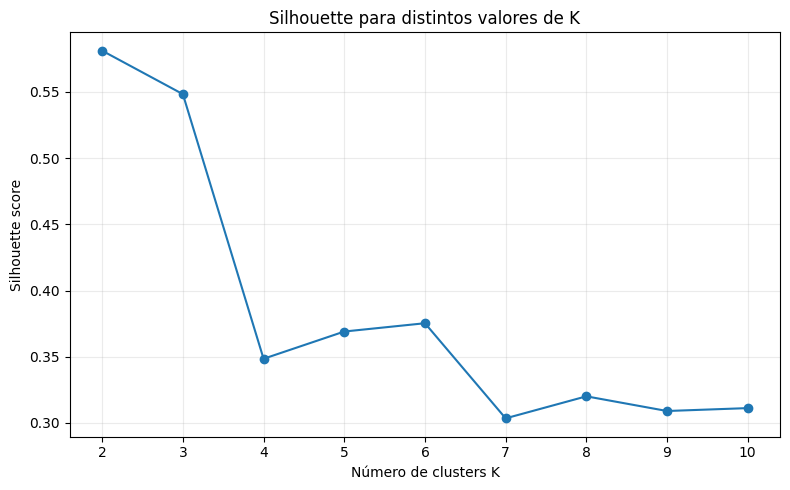

Figura guardada en: salidas_clustering/07_silhouette_vs_k.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados_k["K"],
    df_resultados_k["Silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters K")
plt.ylabel("Silhouette score")
plt.title("Silhouette para distintos valores de K")
plt.xticks(df_resultados_k["K"])
plt.grid(alpha=0.25)
guardar_y_mostrar("07_silhouette_vs_k.png")

## 12. Elegir \(K\): no usar una sola métrica de forma ciega

El método del codo y silhouette responden preguntas relacionadas pero no idénticas.

Además conviene mirar:

- tamaño de los clusters;
- estabilidad;
- presencia de outliers;
- interpretación de negocio.

En la siguiente celda dejamos dos modos:

1. **automático**: toma el \(K\) con mayor silhouette;
2. **manual**: permite probar otro \(K\) para discusión en clase.

In [ ]:
k_silhouette = int(
    df_resultados_k.loc[
        df_resultados_k["Silhouette"].idxmax(),
        "K"
    ]
)

if USAR_K_AUTOMATICO:
    K_FINAL = k_silhouette
else:
    K_FINAL = K_MANUAL

print("K sugerido por silhouette:", k_silhouette)
print("K que usaremos:", K_FINAL)

K sugerido por silhouette: 2
K que usaremos: 2


# 13. Entrenar el K-Means final

In [ ]:
modelo_final = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=N_INIT,
    random_state=RANDOM_STATE
)

clusters = modelo_final.fit_predict(X_scaled)

silhouette_final = silhouette_score(
    X_scaled,
    clusters
)

print("Inercia final:", round(modelo_final.inertia_, 4))
print("Silhouette final:", round(silhouette_final, 4))

print("\nNúmero de clientes por cluster:")
print(pd.Series(clusters).value_counts().sort_index())

Inercia final: 1954.0281
Silhouette final: 0.5811

Número de clientes por cluster:
0    400
1     40
Name: count, dtype: int64


In [ ]:
df_resultado = df.copy()
df_resultado["Cluster"] = clusters

display(df_resultado.head())

df_resultado.to_csv(
    RUTA_SALIDAS / "clientes_clusterizados.csv",
    index=False
)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,0


# 14. Visualizar clusters en dos variables

Para dibujar los centroides en las unidades originales usamos:

```python
scaler.inverse_transform(...)
```

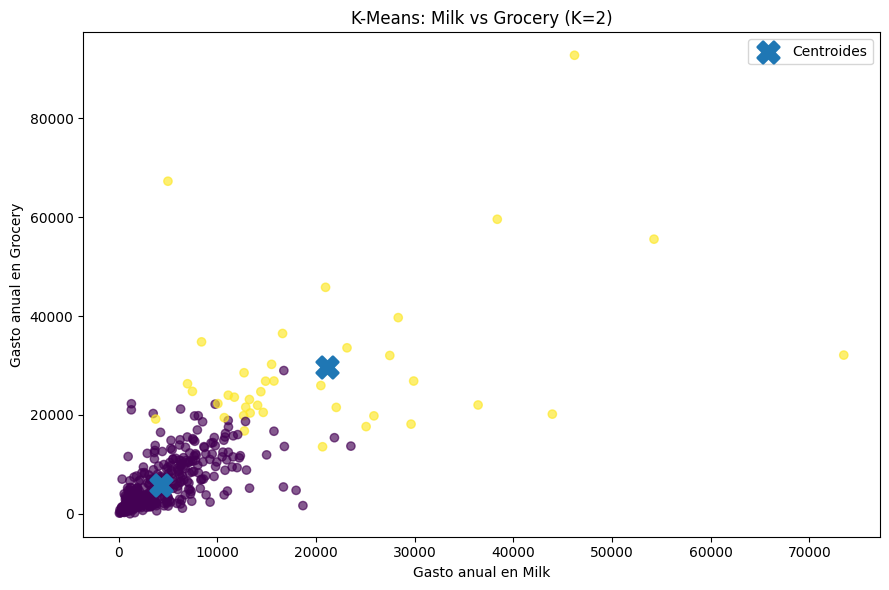

Figura guardada en: salidas_clustering/08_clusters_milk_grocery.png


In [ ]:
centroides_originales = scaler.inverse_transform(
    modelo_final.cluster_centers_
)

centroides_originales_df = pd.DataFrame(
    centroides_originales,
    columns=VARIABLES_GASTO
)

plt.figure(figsize=(9, 6))

plt.scatter(
    X["Milk"],
    X["Grocery"],
    c=clusters,
    alpha=0.65
)

plt.scatter(
    centroides_originales_df["Milk"],
    centroides_originales_df["Grocery"],
    marker="X",
    s=240,
    linewidths=2,
    label="Centroides"
)

plt.xlabel("Gasto anual en Milk")
plt.ylabel("Gasto anual en Grocery")
plt.title(f"K-Means: Milk vs Grocery (K={K_FINAL})")
plt.legend()
guardar_y_mostrar("08_clusters_milk_grocery.png")

# 15. PCA solamente para visualizar las seis dimensiones

K-Means se entrenó usando **las seis variables**.

PCA se utiliza aquí después del clustering para proyectar los datos a dos dimensiones y poder dibujarlos.

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

centroides_pca = pca.transform(
    modelo_final.cluster_centers_
)

var_exp = pca.explained_variance_ratio_

print(
    "Varianza explicada por PC1 y PC2:",
    np.round(var_exp, 4)
)

Varianza explicada por PC1 y PC2: [0.4408 0.2838]


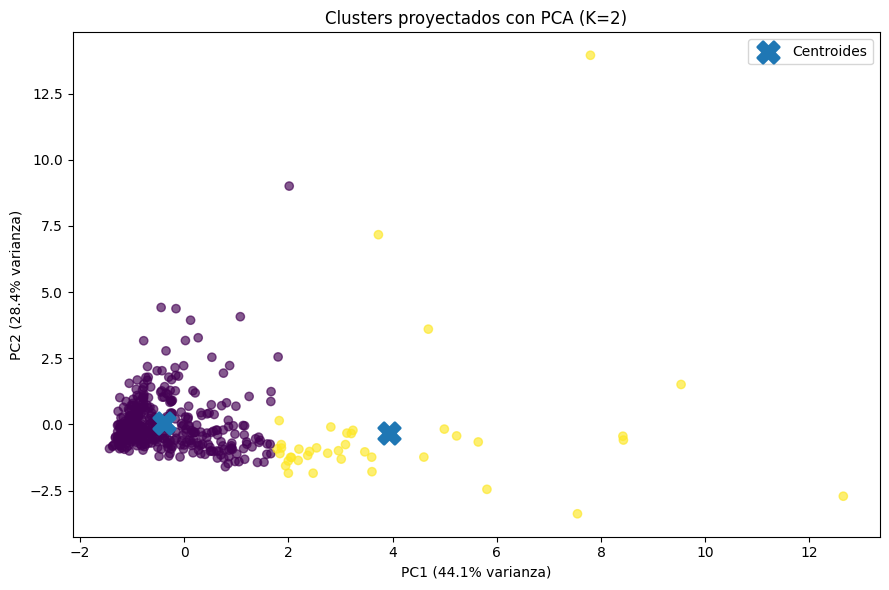

Figura guardada en: salidas_clustering/09_clusters_pca.png


In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    alpha=0.65
)

plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    marker="X",
    s=240,
    linewidths=2,
    label="Centroides"
)

plt.xlabel(f"PC1 ({100*var_exp[0]:.1f}% varianza)")
plt.ylabel(f"PC2 ({100*var_exp[1]:.1f}% varianza)")
plt.title(f"Clusters proyectados con PCA (K={K_FINAL})")
plt.legend()
guardar_y_mostrar("09_clusters_pca.png")

# 16. Silhouette a nivel de cada observación

El promedio puede ocultar casos problemáticos.

Vamos a mirar el coeficiente silhouette de cada cliente.

In [ ]:
sil_individual = silhouette_samples(
    X_scaled,
    clusters
)

df_sil = pd.DataFrame({
    "Cluster": clusters,
    "Silhouette_individual": sil_individual
})

display(
    df_sil.groupby("Cluster")
    ["Silhouette_individual"]
    .agg(["count", "mean", "min", "max"])
    .round(4)
)

,count,mean,min,max
Cluster,,,,
0,400,0.6316,0.0603,0.7491
1,40,0.0761,-0.2791,0.3448


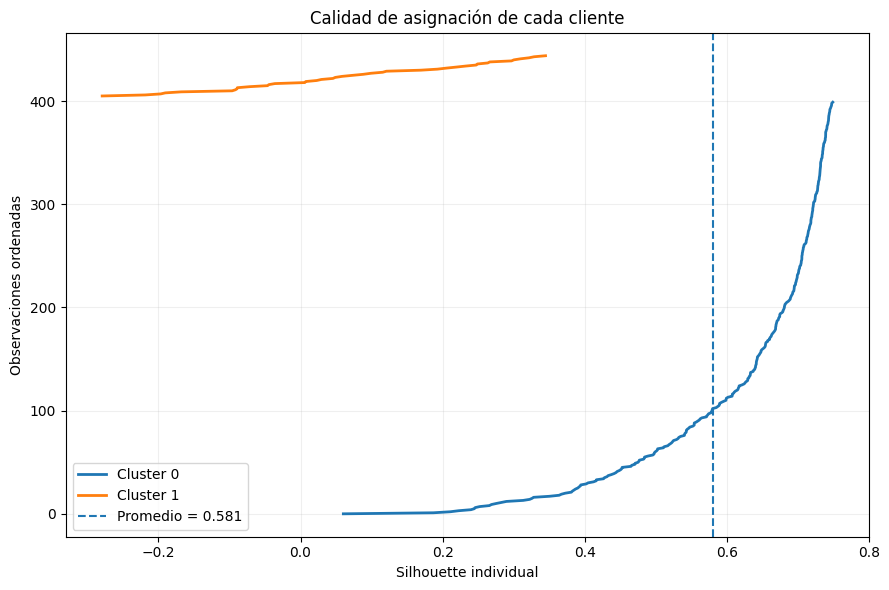

Figura guardada en: salidas_clustering/10_silhouette_individual.png


In [ ]:
plt.figure(figsize=(9, 6))

inicio = 0

for cluster_id in sorted(np.unique(clusters)):

    valores = np.sort(
        sil_individual[clusters == cluster_id]
    )

    indices = np.arange(
        inicio,
        inicio + len(valores)
    )

    plt.plot(
        valores,
        indices,
        linewidth=2,
        label=f"Cluster {cluster_id}"
    )

    inicio += len(valores) + 5

plt.axvline(
    silhouette_final,
    linestyle="--",
    label=f"Promedio = {silhouette_final:.3f}"
)

plt.xlabel("Silhouette individual")
plt.ylabel("Observaciones ordenadas")
plt.title("Calidad de asignación de cada cliente")
plt.legend()
plt.grid(alpha=0.2)
guardar_y_mostrar("10_silhouette_individual.png")

# 17. Interpretar los clusters

El algoritmo solamente entrega etiquetas como:

\[
0,\;1,\;2,\ldots
\]

Esos números **no tienen significado por sí mismos**.

Para descubrir qué representa cada grupo, calculamos el gasto promedio de sus clientes.

In [ ]:
perfil_original = (
    df_resultado
    .groupby("Cluster")[VARIABLES_GASTO]
    .mean()
)

display(perfil_original.round(1))

perfil_original.to_csv(
    RUTA_SALIDAS / "perfil_clusters_unidades_originales.csv"
)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,11983.6,4260.9,5782.8,3056.1,1773.7,1302.7
1,12167.3,21150.1,29635.7,3230.3,13959.3,3746.7


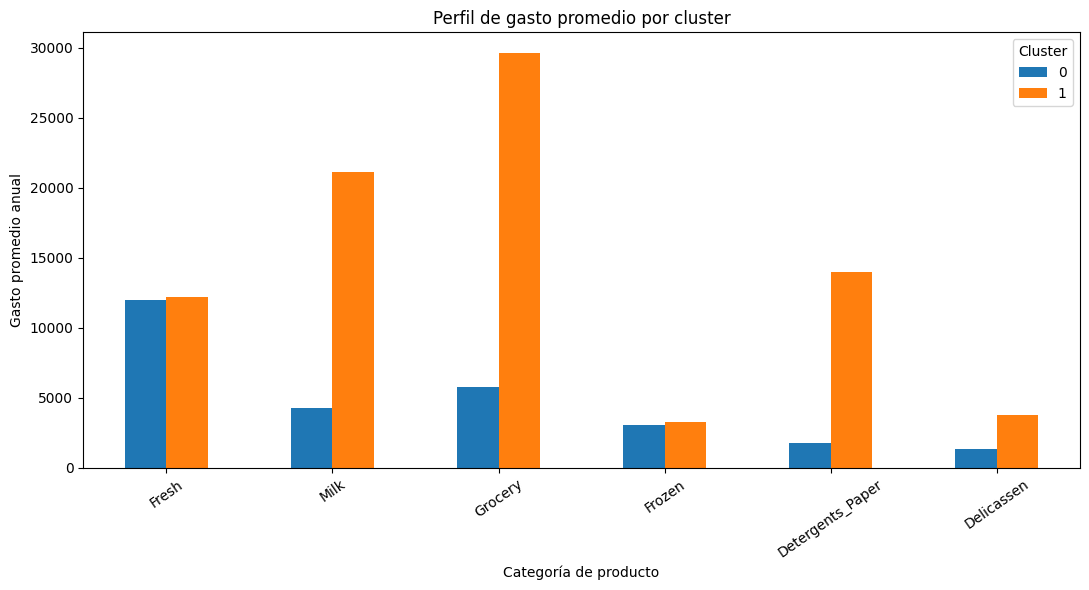

Figura guardada en: salidas_clustering/11_perfil_clusters_original.png


In [ ]:
plt.figure(figsize=(11, 6))

perfil_original.T.plot(
    kind="bar",
    ax=plt.gca()
)

plt.xlabel("Categoría de producto")
plt.ylabel("Gasto promedio anual")
plt.title("Perfil de gasto promedio por cluster")
plt.xticks(rotation=35)
plt.legend(title="Cluster")
guardar_y_mostrar("11_perfil_clusters_original.png")

## 18. Perfil estandarizado

Los valores originales son útiles para negocio, pero algunas categorías tienen escalas muy distintas.

Los centroides estandarizados permiten responder:

> ¿En qué categorías este cluster compra más o menos que el cliente promedio?

In [ ]:
perfil_z = pd.DataFrame(
    modelo_final.cluster_centers_,
    columns=VARIABLES_GASTO
)

perfil_z.index.name = "Cluster"

display(perfil_z.round(2))

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,-0.00,-0.21,-0.23,-0.00,-0.23,-0.08
1,0.01,2.08,2.28,0.03,2.33,0.79


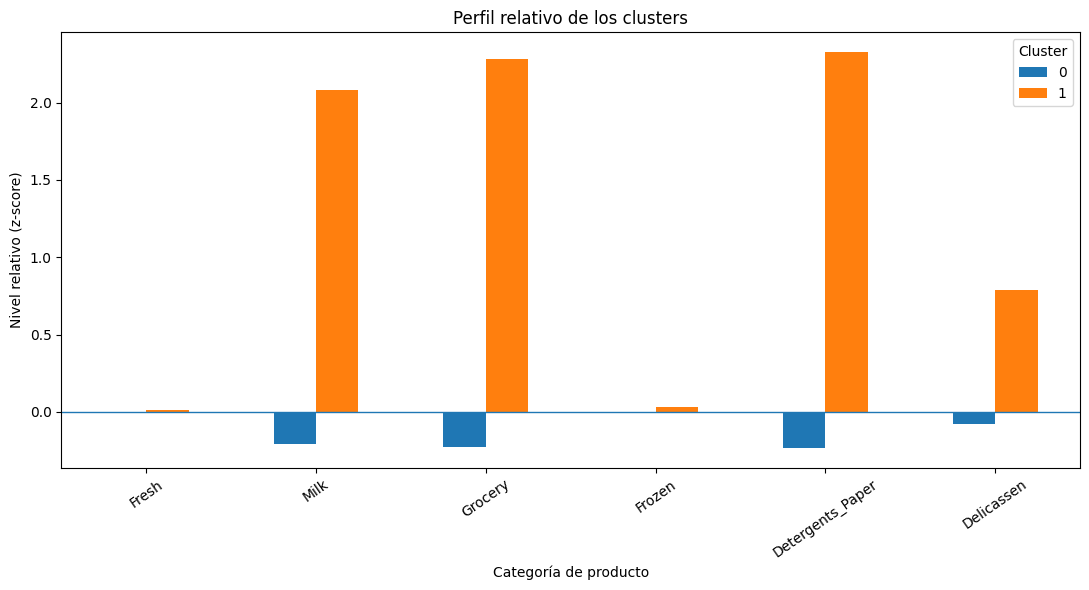

Figura guardada en: salidas_clustering/12_perfil_clusters_estandarizado.png


In [ ]:
plt.figure(figsize=(11, 6))

perfil_z.T.plot(
    kind="bar",
    ax=plt.gca()
)

plt.axhline(0, linewidth=1)

plt.xlabel("Categoría de producto")
plt.ylabel("Nivel relativo (z-score)")
plt.title("Perfil relativo de los clusters")
plt.xticks(rotation=35)
plt.legend(title="Cluster")
guardar_y_mostrar("12_perfil_clusters_estandarizado.png")

# 19. Comprobación externa opcional

`Channel` y `Region` **no participaron en el clustering**.

Una vez encontrados los grupos podemos mirar si tienen alguna relación con esas variables conocidas.

Esto no convierte el procedimiento en supervisado: es una herramienta posterior de interpretación.

In [ ]:
tabla_channel = pd.crosstab(
    df_resultado["Cluster"],
    df_resultado["Channel"],
    normalize="index"
)

tabla_region = pd.crosstab(
    df_resultado["Cluster"],
    df_resultado["Region"],
    normalize="index"
)

print("Proporción de Channel dentro de cada cluster:")
display(tabla_channel.round(3))

print("Proporción de Region dentro de cada cluster:")
display(tabla_region.round(3))

Proporción de Channel dentro de cada cluster:


Channel,1,2
Cluster,,
0,0.74,0.26
1,0.05,0.95


Proporción de Region dentro de cada cluster:


Region,1,2,3
Cluster,,,
0,0.175,0.098,0.728
1,0.175,0.200,0.625


# 20. Experimentos para la clase

Prueba modificar:

```python
USAR_K_AUTOMATICO = False
K_MANUAL = 3
```

y después repetir con \(K=2,3,4,5\).

Preguntas para discutir:

1. ¿Los clusters son más compactos al aumentar \(K\)?
2. ¿Por qué la inercia siempre tiende a disminuir?
3. ¿El mayor silhouette produce necesariamente los grupos más útiles?
4. ¿Aparecen clusters muy pequeños?
5. ¿Qué efecto tienen los clientes con gastos extremadamente altos?
6. ¿Cómo cambia el perfil comercial de los grupos?
7. ¿Qué diferencia conceptual existe entre **descubrir clusters** y **predecir una etiqueta**?

# Conclusión

La cadena conceptual completa es:

\[
\boxed{\text{Datos sin etiquetas}}
\rightarrow
\boxed{\text{Escalado}}
\rightarrow
\boxed{\text{K-Means}}
\rightarrow
\boxed{\text{Inercia}}
\rightarrow
\boxed{\text{Codo + Silhouette}}
\rightarrow
\boxed{\text{Elegir }K}
\rightarrow
\boxed{\text{Interpretar clusters}}
\]

La idea más importante es que K-Means **siempre puede fabricar \(K\) grupos si se lo pedimos**.

La tarea del analista no termina al ejecutar `.fit_predict()`: debe evaluar si esos grupos son compactos, estables, suficientemente separados y, sobre todo, **interpretables en el contexto del problema**.